Ridge MSE: 0.98236535846287
Lasso MSE: 1.0033843624547254
Ridge Coeff: [ 1.19903926  0.50108601 -0.00354359  0.06972891  0.01086815]
Lasso Coeff: [ 1.1111953   0.39406031 -0.          0.          0.        ]


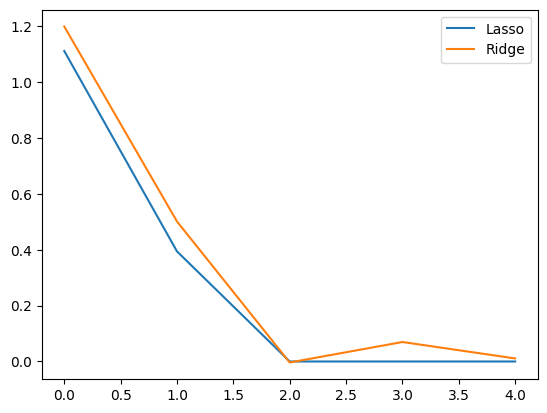

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# Data (noisy)
X = np.random.rand(200, 5)
y = X[:, 0]*4 + X[:, 1]*2 + np.random.randn(200)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)
pred_lasso = lasso.predict(X_test)

print("Ridge MSE:", mean_squared_error(y_test, pred_ridge))
print("Lasso MSE:", mean_squared_error(y_test, pred_lasso))

print("Ridge Coeff:", ridge.coef_)
print("Lasso Coeff:", lasso.coef_)
plt.plot(lasso.coef_, label="Lasso")
plt.plot(ridge.coef_, label="Ridge")
plt.legend()
plt.show()

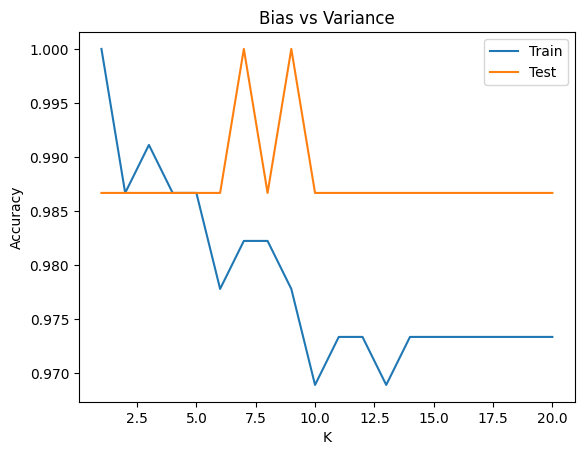

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

X = np.random.rand(300, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

train_acc = []
test_acc = []

k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(k_values, train_acc, label="Train")
plt.plot(k_values, test_acc, label="Test")
plt.legend()
plt.title("Bias vs Variance")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [5]:
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = np.random.rand(100, 3)
y = X[:, 0]*3 + X[:, 1]*2 + np.random.randn(100)

# Models
model1 = LinearRegression()
model2 = Ridge(alpha=1.0)
model3 = RandomForestRegressor(n_estimators=100)

# CV
scores1 = cross_val_score(model1, X, y, cv=5)
scores2 = cross_val_score(model2, X, y, cv=5)
scores3 = cross_val_score(model3, X, y, cv=5)

print("Linear Avg:", scores1.mean())
print("Ridge Avg :", scores2.mean())
print("RF Avg    :", scores3.mean())

Linear Avg: 0.5195974156740084
Ridge Avg : 0.5163253117013482
RF Avg    : 0.34221573155896423


Linear MSE: 0.7497782943229002
Ridge MSE: 0.7506987706545164
Lasso MSE: 0.7876034261794623
Ridge Coeff: [ 1.16521228e+00  4.72403270e-01 -2.04735188e-04]
Lasso Coeff: [1.08516355 0.38696615 0.        ]
Ridge CV Scores: [0.4152557  0.65011782 0.67132129 0.61310978 0.59573662]
Ridge Avg: 0.5891082428732866


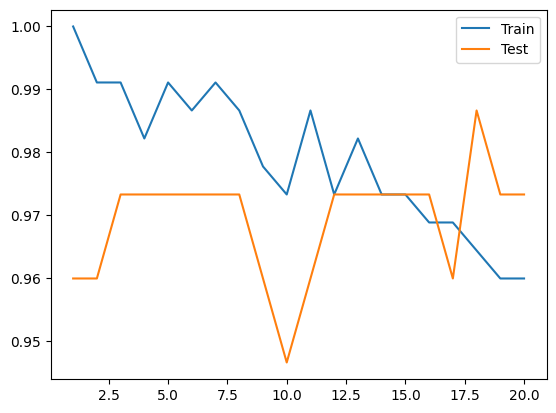

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, accuracy_score

np.random.seed(42)

X = np.random.rand(200, 3)
y = X[:, 0]*4 + X[:, 1]*2 + np.random.randn(200)

X_train, X_test, y_train, y_test = train_test_split(X, y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

linear = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

linear.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

pred_linear = linear.predict(X_test)
pred_ridge = ridge.predict(X_test)
pred_lasso = lasso.predict(X_test)

print("Linear MSE:", mean_squared_error(y_test, pred_linear))
print("Ridge MSE:", mean_squared_error(y_test, pred_ridge))
print("Lasso MSE:", mean_squared_error(y_test, pred_lasso))

print("Ridge Coeff:", ridge.coef_)
print("Lasso Coeff:", lasso.coef_)

cv_ridge = cross_val_score(ridge, X, y, cv=5)
print("Ridge CV Scores:", cv_ridge)
print("Ridge Avg:", cv_ridge.mean())

X2 = np.random.rand(300, 2)
y2 = (X2[:, 0] + X2[:, 1] > 1).astype(int)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2)

scaler2 = StandardScaler()
X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

train_acc = []
test_acc = []

k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train2, y_train2)
    train_acc.append(accuracy_score(y_train2, model.predict(X_train2)))
    test_acc.append(accuracy_score(y_test2, model.predict(X_test2)))

plt.plot(k_values, train_acc, label="Train")
plt.plot(k_values, test_acc, label="Test")
plt.legend()
plt.show()